# Projeto Final - Predição de Risco de AVC (Stroke Prediction)

# Introdução

O Acidente Vascular Cerebral (AVC) é uma das principais causas de morte e incapacidade no mundo. A identificação precoce de pacientes com maior risco pode auxiliar profissionais da saúde na tomada de decisões preventivas.

Neste projeto será utilizado o dataset Stroke Prediction para desenvolver modelos de Machine Learning capazes de prever a ocorrência de AVC a partir de informações clínicas e demográficas dos pacientes.

Durante o desenvolvimento serão realizadas as seguintes etapas:

- Análise Exploratória dos Dados (EDA);
- Pré-processamento;
- Construção de um modelo baseline;
- Treinamento de diferentes algoritmos;
- Comparação entre os modelos;
- Escolha do melhor modelo;
- Otimização utilizando GridSearchCV;
- Avaliação final e conclusão.

# Importação das bibliotecas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"]=(8,5)

In [ ]:
!pip install -q imbalanced-learn

In [ ]:
import pandas as pd

# Carregando o dataset
df = pd.read_csv('/content/healthcare-dataset-stroke-data.csv')

# Verificando o carregamento
print("Dataset carregado com sucesso!")
display(df.head())

Dataset carregado com sucesso!


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


# Visualização dos Dados

In [ ]:
print("="*60)
print("INFORMAÇÕES DO DATASET")
print("="*60)

display(df.head())

print("\nDimensões:", df.shape)

print("\nTipos das variáveis")
display(df.info())

print("\nEstatísticas descritivas")
display(df.describe())

print("\nValores nulos")
display(df.isnull().sum())

print("\nDuplicados:", df.duplicated().sum())

INFORMAÇÕES DO DATASET


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1



Dimensões: (5110, 12)

Tipos das variáveis
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


None


Estatísticas descritivas


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000



Valores nulos


,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201



Duplicados: 0


# Análise Exploratória de Dados (EDA)

## Gráfico 1 - Histograma da Idade

*   Item de lista
*   Item de lista



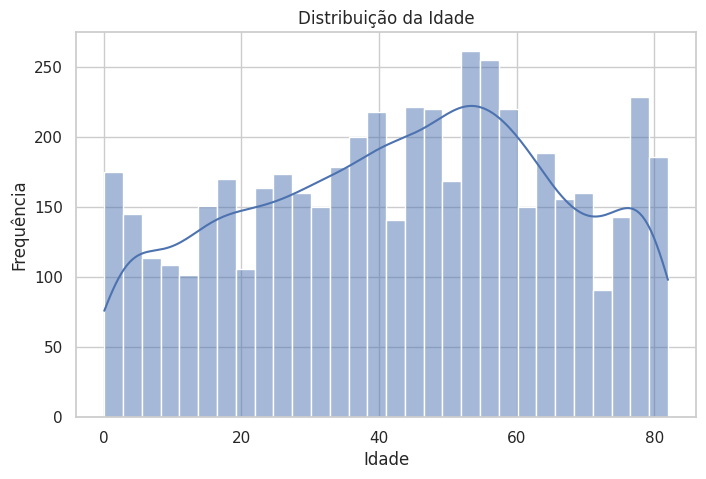

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["age"], bins=30, kde=True)
plt.title("Distribuição da Idade")
plt.xlabel("Idade")
plt.ylabel("Frequência")
plt.show()

### Observações sobre a Distribuição da Idade

O histograma mostra uma distribuição relativamente bem espalhada, mas com uma concentração visível em idades mais avançadas. Como o AVC é uma condição frequentemente associada ao envelhecimento, entender essa distribuição é vital. Observamos que o dataset cobre desde crianças até idosos, o que exigirá que o modelo identifique como o risco escala ao longo dos anos.

## Gráfico 2 - Boxplot do BMI

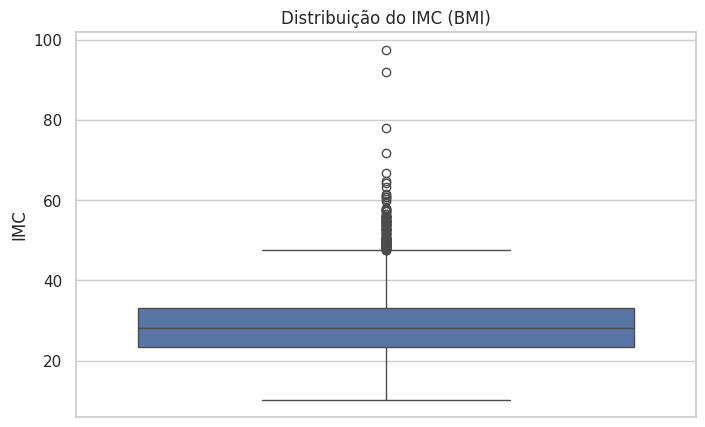

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(y=df["bmi"])
plt.title("Distribuição do IMC (BMI)")
plt.ylabel("IMC")
plt.show()

### Observações sobre a Distribuição do IMC

O boxplot do IMC (BMI) revela uma grande quantidade de *outliers* na parte superior da escala (valores acima de 40-50). A mediana está em torno de 28, o que já indica sobrepeso segundo a OMS. Esses valores extremos são importantes, pois a obesidade é um fator de risco conhecido para doenças cardiovasculares.

## Gráfico 3 – Distribuição da variável alvo

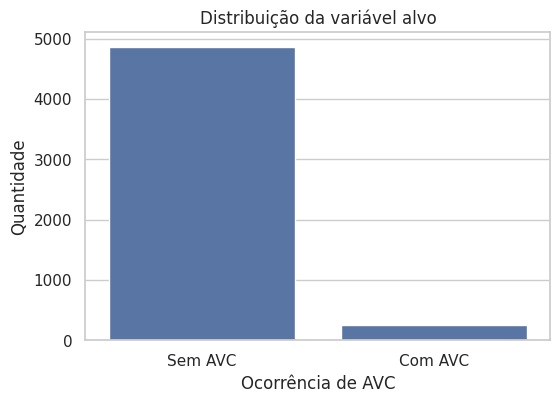

In [ ]:
plt.figure(figsize=(6,4))

ax = sns.countplot(data=df, x="stroke")
ax.set_xticks([0, 1])
ax.set_xticklabels(["Sem AVC", "Com AVC"])

plt.title("Distribuição da variável alvo")
plt.xlabel("Ocorrência de AVC")
plt.ylabel("Quantidade")

plt.show()

### Observações sobre a Distribuição da Variável Alvo

Identificamos um **desbalanceamento severo**: a vasta maioria dos casos é de 'Sem AVC'. Em problemas médicos, isso é comum, mas desafiador para o aprendizado de máquina. Se não tratado, o modelo pode simplesmente aprender a prever 'Sem AVC' para todos e ainda assim ter uma acurácia alta, por isso usaremos técnicas como `class_weight='balanced'`.

## Gráfico 4 – Heatmap de Correlação

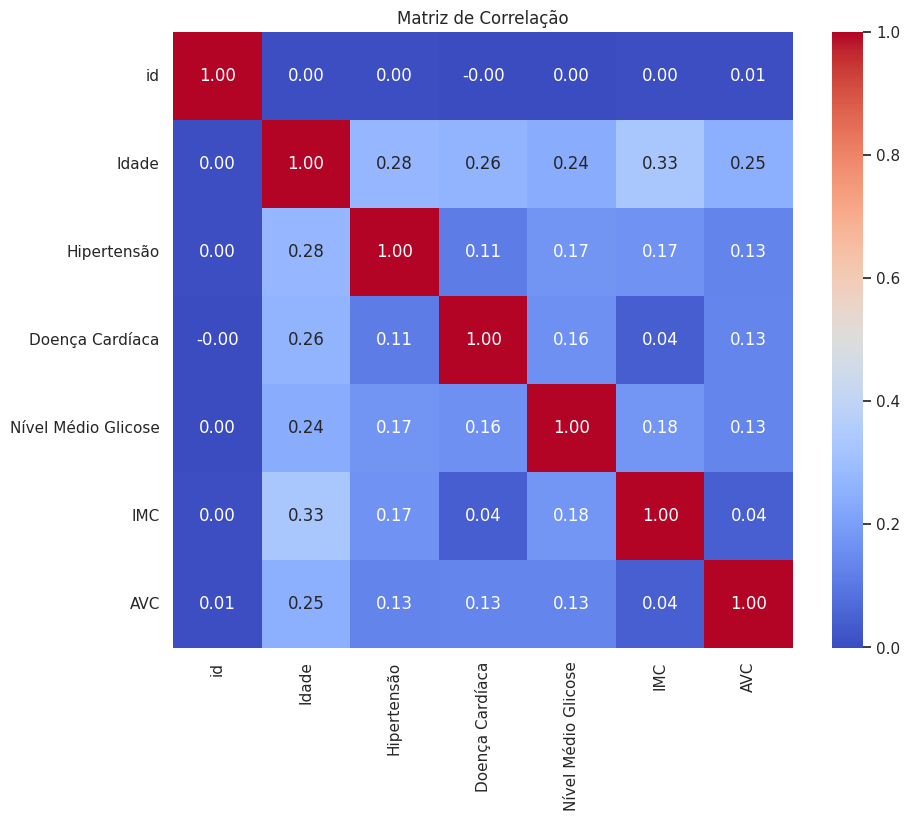

In [ ]:
plt.figure(figsize=(10,8))

corr_data = df.select_dtypes(include=np.number).rename(columns={
    'age': 'Idade',
    'hypertension': 'Hipertensão',
    'heart_disease': 'Doença Cardíaca',
    'avg_glucose_level': 'Nível Médio Glicose',
    'bmi': 'IMC',
    'stroke': 'AVC'
})
corr = corr_data.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlação")
plt.show()

### Observações sobre a Correlação entre Variáveis Numéricas

A matriz de correlação mostra que a **Idade** é a variável com maior correlação positiva com o **AVC (stroke)** (0.25). Também notamos que Idade e Hipertensão/Doença Cardíaca andam juntas. O IMC, curiosamente, tem uma correlação linear baixa com o AVC diretamente, sugerindo que sua influência pode ser mediada por outros fatores ou não ser estritamente linear.

## Gráfico 5 - Idade por ocorrência de AVC

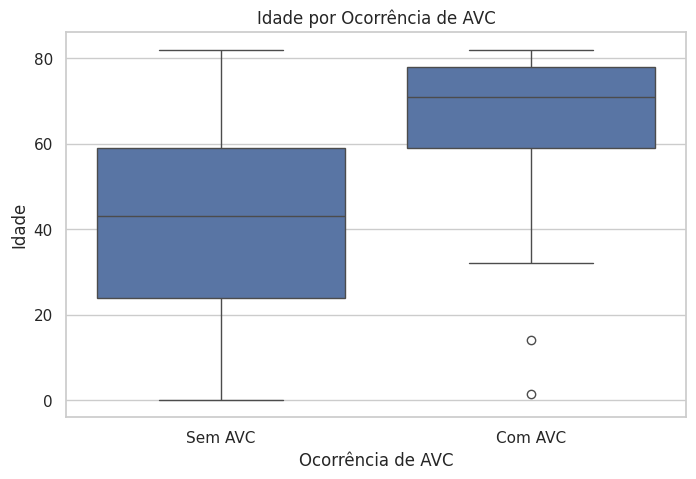

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="stroke", y="age")
plt.title("Idade por Ocorrência de AVC")
plt.xlabel("Ocorrência de AVC")
plt.ylabel("Idade")
plt.xticks([0, 1], ["Sem AVC", "Com AVC"])
plt.show()

### Observações sobre Idade e AVC

Este boxplot comparativo é um dos mais reveladores: a distribuição de idade para quem sofreu AVC é muito mais alta e compacta (concentrada entre 60 e 80 anos). Para o grupo sem AVC, a distribuição é muito mais ampla. Isso confirma estatisticamente que a idade será provavelmente a *feature* mais importante para o nosso modelo preditivo.

# Pré-Processamento

### Etapas de Preparação dos Dados

Nesta fase, preparamos os dados para o modelo seguindo estas etapas:
1. **Remoção de Identificadores**: O `id` foi removido por não possuir valor preditivo.
2. **Tratamento de Dados Numéricos**: Utilizamos o `SimpleImputer` com a estratégia de mediana para preencher valores ausentes (como no IMC) e o `StandardScaler` para normalizar as grandezas, garantindo que variáveis com valores altos não dominem o modelo.
3. **Tratamento de Dados Categóricos**: Aplicamos o `OneHotEncoder` para transformar variáveis de texto em representações numéricas binárias.
4. **Pipeline e ColumnTransformer**: Integramos tudo em um fluxo automatizado para evitar erros de processamento e garantir que os mesmos critérios sejam aplicados nos dados de teste.

In [ ]:
df = df.drop(columns=["id"])

X = df.drop("stroke", axis=1)
y = df["stroke"]

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Variáveis numéricas:", numeric_features)
print("Variáveis categóricas:", categorical_features)

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nDimensões dos conjuntos:")
print(f"Treino: {X_train.shape}")
print(f"Teste : {X_test.shape}")

Variáveis numéricas: ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']
Variáveis categóricas: ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

Dimensões dos conjuntos:
Treino: (4088, 10)
Teste : (1022, 10)


# Baseline (Regressão Logística)

### Por que a Regressão Logística?

Utilizamos a **Regressão Logística** como nosso modelo baseline por ser um algoritmo linear simples, rápido e de fácil interpretação.

O ponto crucial aqui é o uso do parâmetro `class_weight='balanced'`. Como vimos na EDA, há pouquíssimos casos de AVC no dataset. Sem esse ajuste, o modelo ignoraria a classe minoritária. Com o peso balanceado, o algoritmo penaliza mais fortemente o erro na classe 'Com AVC', buscando um melhor equilíbrio entre sensibilidade (Recall) e precisão.

BASELINE - REGRESSÃO LOGÍSTICA
Acurácia: 0.7456

Relatório de Classificação
              precision    recall  f1-score   support

           0       0.99      0.74      0.85       972
           1       0.14      0.80      0.24        50

    accuracy                           0.75      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.94      0.75      0.82      1022



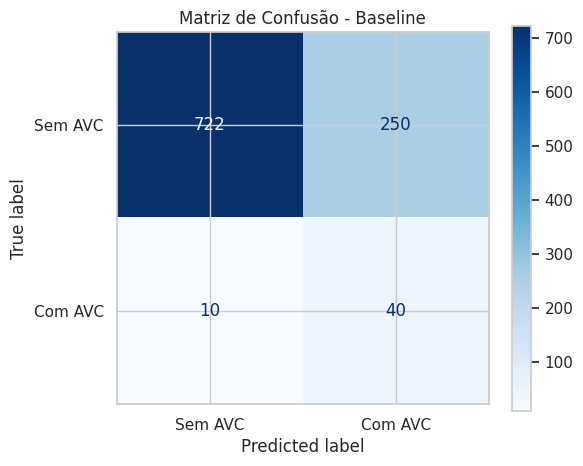

In [ ]:
baseline = Pipeline(
    steps=[
        ("preprocessamento", preprocessor),
        ("modelo", LogisticRegression(max_iter=1000, class_weight="balanced"))
    ]
)

baseline.fit(X_train, y_train)

y_pred = baseline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("=" * 70)
print("BASELINE - REGRESSÃO LOGÍSTICA")
print("=" * 70)

print(f"Acurácia: {accuracy:.4f}")

print("\nRelatório de Classificação")
print(classification_report(y_test, y_pred))

fig, ax = plt.subplots(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Sem AVC", "Com AVC"],
    cmap="Blues",
    ax=ax
)

plt.title("Matriz de Confusão - Baseline")
plt.show()

# Modelos

## Modelo 1 - Árvore de Decisão

### Por que testar múltiplos algoritmos?

Após estabelecermos o baseline com Regressão Logística, é fundamental testar diferentes famílias de algoritmos. Cada modelo possui uma 'forma' diferente de aprender os dados:

1.  **Modelos Baseados em Árvores**: Capturam relações não-lineares e interações entre variáveis de forma natural.
2.  **Modelos Baseados em Instâncias (KNN)**: Classificam novos pontos com base na proximidade (similaridade) com dados conhecidos.

O objetivo aqui é verificar se a complexidade adicional desses modelos traz um ganho real no **Recall**, que é nossa prioridade clínica.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

tree = Pipeline(
    steps=[
        ("preprocessamento", preprocessor),
        ("modelo", DecisionTreeClassifier(
            random_state=42,
            class_weight="balanced"
        ))
    ]
)

tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

acc_tree = accuracy_score(y_test, y_pred_tree)
prec_tree = precision_score(y_test, y_pred_tree)
rec_tree = recall_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)

print("="*70)
print("ÁRVORE DE DECISÃO")
print("="*70)
print(f"Acurácia : {acc_tree:.4f}")
print(f"Precisão : {prec_tree:.4f}")
print(f"Recall   : {rec_tree:.4f}")
print(f"F1-score : {f1_tree:.4f}")
print()
print(classification_report(y_test,y_pred_tree))

ÁRVORE DE DECISÃO
Acurácia : 0.9286
Precisão : 0.1892
Recall   : 0.1400
F1-score : 0.1609

              precision    recall  f1-score   support

           0       0.96      0.97      0.96       972
           1       0.19      0.14      0.16        50

    accuracy                           0.93      1022
   macro avg       0.57      0.55      0.56      1022
weighted avg       0.92      0.93      0.92      1022



### Matriz de Confusão

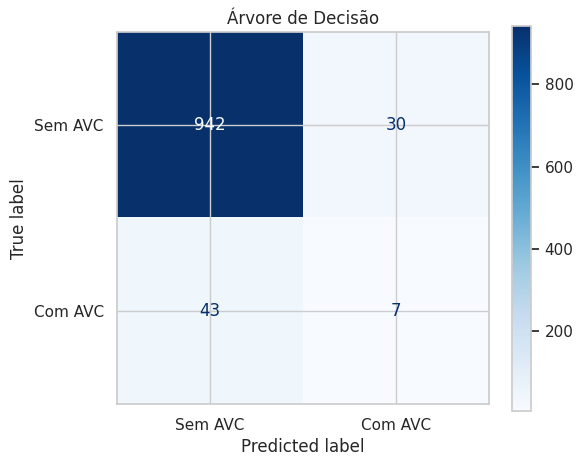

In [ ]:
fig, ax = plt.subplots(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(

    y_test,
    y_pred_tree,
    display_labels=["Sem AVC","Com AVC"],
    cmap="Blues",
    ax=ax

)

plt.title("Árvore de Decisão")
plt.show()

### Observações


### Sobre a Árvore de Decisão

A Árvore de Decisão é intuitiva, mas propensa ao *overfitting* (decorar o treino). Aqui, utilizamos o parâmetro `class_weight='balanced'` para forçar o algoritmo a dar atenção aos raros casos de AVC. Se o modelo apresentar uma acurácia muito alta no treino mas um Recall baixo no teste, saberemos que ele não conseguiu generalizar o padrão de risco.

## Modelo 2 — Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

forest = Pipeline(
    steps=[
        ("preprocessamento", preprocessor),
        ("modelo",
            RandomForestClassifier(
             random_state=42,
             class_weight="balanced_subsample",
             n_estimators=500,
             max_depth=10,
             min_samples_leaf=3
            )
        )
    ]
)

forest.fit(X_train,y_train)

y_pred_forest = forest.predict(X_test)
acc_forest = accuracy_score(y_test,y_pred_forest)
prec_forest = precision_score(y_test,y_pred_forest)
rec_forest = recall_score(y_test,y_pred_forest)
f1_forest = f1_score(y_test,y_pred_forest)

print("="*70)
print("RANDOM FOREST")
print("="*70)
print(f"Acurácia : {acc_forest:.4f}")
print(f"Precisão : {prec_forest:.4f}")
print(f"Recall   : {rec_forest:.4f}")
print(f"F1-score : {f1_forest:.4f}")
print()
print(classification_report(y_test,y_pred_forest))

RANDOM FOREST
Acurácia : 0.9080
Precisão : 0.1944
Recall   : 0.2800
F1-score : 0.2295

              precision    recall  f1-score   support

           0       0.96      0.94      0.95       972
           1       0.19      0.28      0.23        50

    accuracy                           0.91      1022
   macro avg       0.58      0.61      0.59      1022
weighted avg       0.92      0.91      0.92      1022



### Matriz de Confusão

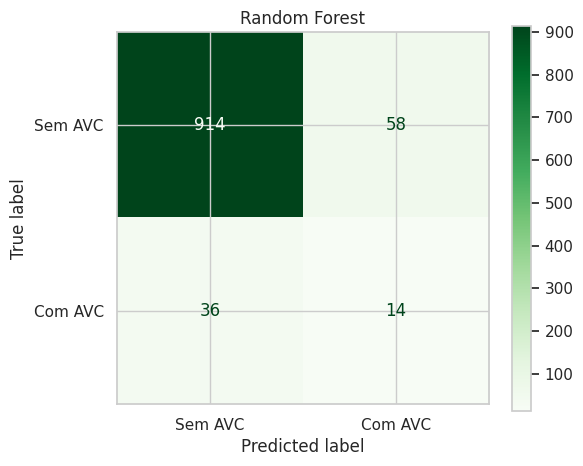

In [ ]:
fig, ax = plt.subplots(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_forest,
    display_labels=["Sem AVC","Com AVC"],
    cmap="Greens",
    ax=ax
)

plt.title("Random Forest")
plt.show()

### Observação

### A Força do Random Forest

O Random Forest é uma 'floresta' de árvores de decisão. Ele utiliza a técnica de *Ensemble* (votação) para reduzir o erro e o overfitting.

*   **Vantagem**: Geralmente mais robusto que uma árvore única.
*   **Ajuste**: Usamos `class_weight='balanced_subsample'`, que calcula o peso das classes para cada árvore individualmente dentro da floresta, tentando mitigar o efeito do desbalanceamento de forma mais agressiva.

## Modelo 3 - KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn = Pipeline(
    steps=[
        ("preprocessamento", preprocessor),
        ("modelo",
            KNeighborsClassifier(
                n_neighbors = 9,
                weights="distance"
            )
        )
    ]
)

knn.fit(X_train,y_train)
y_pred_knn = knn.predict(X_test)

acc_knn = accuracy_score(y_test,y_pred_knn)
prec_knn = precision_score(y_test,y_pred_knn)
rec_knn = recall_score(y_test,y_pred_knn)
f1_knn = f1_score(y_test,y_pred_knn)

print("="*70)
print("KNN")
print("="*70)
print(f"Acurácia : {acc_knn:.4f}")
print(f"Precisão : {prec_knn:.4f}")
print(f"Recall   : {rec_knn:.4f}")
print(f"F1-score : {f1_knn:.4f}")
print()
print(classification_report(y_test,y_pred_knn))

KNN
Acurácia : 0.9481
Precisão : 0.0000
Recall   : 0.0000
F1-score : 0.0000

              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022



### O Desafio do KNN

O KNN (K-Nearest Neighbors) encontra dificuldades em dados desbalanceados. Se tivermos 95% de casos 'Sem AVC', a chance de os vizinhos mais próximos de qualquer paciente serem da classe majoritária é altíssima. Tentamos compensar isso usando `weights='distance'`, dando mais peso aos vizinhos que realmente estão perto, para ver se conseguimos isolar os casos de risco.

### Matriz de Confusão

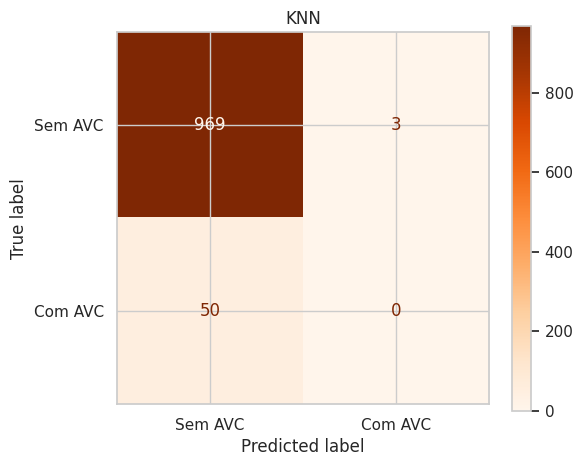

In [ ]:
fig, ax = plt.subplots(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_knn,
    display_labels=["Sem AVC","Com AVC"],
    cmap="Oranges",
    ax=ax
)

plt.title("KNN")
plt.show()

# Comparação dos Modelos

### Consolidando os Resultados

Nesta etapa, reunimos as métricas de todos os modelos testados em um único quadro comparativo. Esta visão é essencial porque, em problemas complexos, um modelo raramente domina todas as métricas simultaneamente.

O desafio aqui é decidir: priorizamos a **Acurácia** (acertar o máximo no geral) ou o **Recall** (identificar o máximo de casos de AVC possível)?

In [ ]:
comparacao = pd.DataFrame({
    "Modelo":[
        "Regressão Logística",
        "Árvore de Decisão",
        "Random Forest",
        "KNN"
    ],
    "Accuracy":[
        accuracy,
        acc_tree,
        acc_forest,
        acc_knn
    ],
    "Precision":[
        precision_score(y_test,y_pred),
        prec_tree,
        prec_forest,
        prec_knn
    ],
    "Recall":[
        recall_score(y_test,y_pred),
        rec_tree,
        rec_forest,
        rec_knn
    ],
    "F1-Score":[
        f1_score(y_test,y_pred),
        f1_tree,
        f1_forest,
        f1_knn
    ]
})

comparacao

,Modelo,Accuracy,Precision,Recall,F1-Score
0,Regressão Logística,0.745597,0.137931,0.80,0.235294
1,Árvore de Decisão,0.928571,0.189189,0.14,0.160920
2,Random Forest,0.908023,0.194444,0.28,0.229508
3,KNN,0.948141,0.000000,0.00,0.000000


### Por que um 'Score Final'?

Como cada métrica conta uma parte da história, criamos um **Score Final ponderado**. No contexto de saúde:

*   **Recall (Peso 0.4)**: É nossa maior prioridade. O custo de não detectar um AVC é muito maior que o custo de um alarme falso.
*   **F1-Score (Peso 0.3)**: Garante que não estamos escolhendo um modelo que 'chuta' positivo para todos (o que daria recall 1.0, mas seria inútil).
*   **Precision (Peso 0.2)**: Mantém uma preocupação mínima com a eficiência dos recursos médicos.
*   **Accuracy (Peso 0.1)**: Tem o menor peso, pois o desbalanceamento a torna pouco confiável sozinha.

### Gráfico Comparativo

<Figure size 1000x600 with 0 Axes>

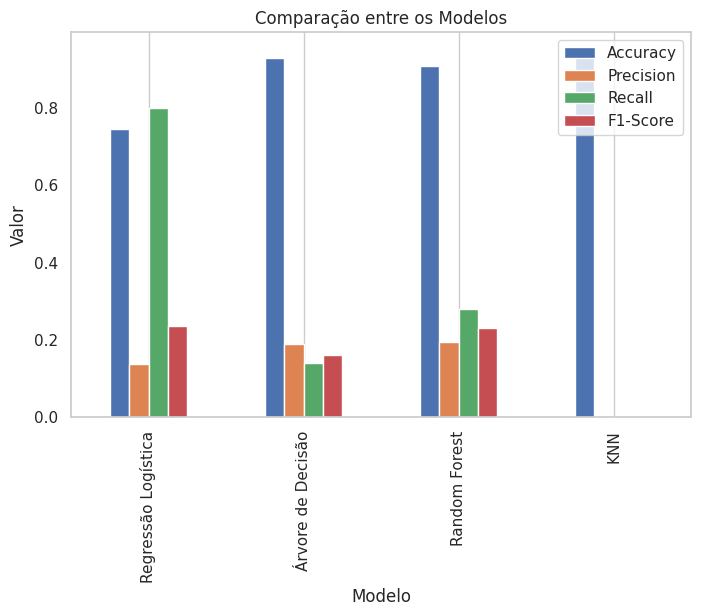

In [ ]:
plt.figure(figsize=(10,6))

comparacao.set_index("Modelo")[["Accuracy","Precision","Recall","F1-Score"]].plot(
    kind="bar"
)

plt.title("Comparação entre os Modelos")
plt.ylabel("Valor")
plt.grid(axis="y")
plt.show()

### Interpretando o Gráfico Comparativo

Ao observar o gráfico, notamos um fenômeno comum em dados desbalanceados:

1.  **Modelos Conservadores (KNN/Árvore)**: Mantêm alta acurácia porque raramente preveem a classe 1 (AVC). Eles 'jogam seguro' com a classe majoritária, mas falham na missão clínica.
2.  **Modelos Audaciosos (Regressão Logística)**: Sacrificam a acurácia geral para maximizar o Recall. Note como a barra de Recall da Regressão Logística se destaca, justificando sua escolha como baseline superior para este problema específico.

### Escolha do Melhor Modelo

In [ ]:
comparacao["Score Final"] = (
    0.10 * comparacao["Accuracy"] +
    0.20 * comparacao["Precision"] +
    0.40 * comparacao["Recall"] +
    0.30 * comparacao["F1-Score"]
)

melhor_modelo = comparacao.sort_values(
    by="Score Final",
    ascending=False
).iloc[0]

print("="*60)
print("MELHOR MODELO")
print("="*60)
print()
print(melhor_modelo)

MELHOR MODELO

Modelo         Regressão Logística
Accuracy                  0.745597
Precision                 0.137931
Recall                         0.8
F1-Score                  0.235294
Score Final               0.492734
Name: 0, dtype: object


# GridSearchCV

### Por que utilizar o GridSearchCV?

Até agora, treinamos os modelos com parâmetros padrão ou escolhas manuais. O **GridSearchCV** automatiza a busca pela melhor combinação de hiperparâmetros, testando exaustivamente uma 'grade' de opções.

Nesta etapa, focamos na **Regressão Logística** (nosso melhor baseline) e no **Random Forest** (que mostrou potencial). O objetivo não é apenas melhorar os números, mas encontrar o ponto de operação do modelo que melhor atende à nossa necessidade clínica.

## GridSearchCV - Regressão Logística (Melhor Modelo)

### Estratégia de Otimização: A escolha do Scoring

Configuramos o GridSearch com `scoring='f1'`.

**Por que F1 e não Recall?**
Se otimizássemos apenas pelo Recall, o modelo poderia aprender que prever 'AVC' para todo mundo é a melhor estratégia (Recall = 100%). Ao usar o F1-Score, forçamos o algoritmo a buscar o melhor equilíbrio possível: queremos identificar o máximo de doentes, mas mantendo uma precisão mínima para que o modelo ainda seja útil na prática médica.

In [ ]:
pipeline_lr = Pipeline(
    steps=[
        ("preprocessamento", preprocessor),
        ("modelo",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced"
            )
        )
    ]
)

parametros_lr = {
    "modelo__C":[
        0.01,
        0.1,
        1,
        10,
        100
    ],
    "modelo__solver":[
        "liblinear",
        "lbfgs"
    ]
}

grid_lr = GridSearchCV(
    estimator=pipeline_lr,
    param_grid=parametros_lr,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

grid_lr.fit(X_train,y_train)

print("="*60)
print("REGRESSÃO LOGÍSTICA OTIMIZADA")
print("="*60)
print()
print("Melhores parâmetros:")
print(grid_lr.best_params_)
print()
print("Melhor Score:")
print(grid_lr.best_score_)

REGRESSÃO LOGÍSTICA OTIMIZADA

Melhores parâmetros:
{'modelo__C': 0.1, 'modelo__solver': 'lbfgs'}

Melhor Score:
0.23531063162439275


### Refinando a Regressão Logística

Aqui ajustamos o parâmetro `C` (força da regularização). Um `C` menor aplica uma regularização mais forte, o que pode ajudar o modelo a ignorar ruídos nos dados e focar nos padrões de risco mais consistentes.

In [ ]:
best_lr = grid_lr.best_estimator_

y_pred_lr = best_lr.predict(X_test)

print(classification_report(
    y_test,
    y_pred_lr,
    zero_division=0
))

              precision    recall  f1-score   support

           0       0.99      0.74      0.85       972
           1       0.14      0.80      0.24        50

    accuracy                           0.75      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.94      0.75      0.82      1022



### Matriz de Confusão

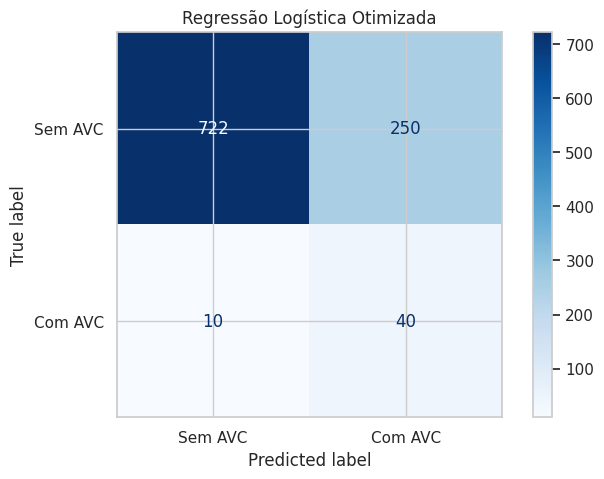

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    display_labels=["Sem AVC","Com AVC"],
    cmap="Blues"
)

plt.title("Regressão Logística Otimizada")
plt.show()

## GridSearchCV - Random Forest

### Explorando a Complexidade do Random Forest

Testamos diferentes profundidades (`max_depth`) e números de árvores (`n_estimators`).

Como este modelo é naturalmente mais complexo que a Regressão Logística, o GridSearch é vital para evitar que ele simplesmente decore os dados de treino (overfitting) e perca sua capacidade de detectar novos casos de AVC no mundo real.

In [ ]:
pipeline_rf = Pipeline(
    steps=[
        ("preprocessamento", preprocessor),
        ("modelo",
            RandomForestClassifier(
                random_state=42,
                class_weight="balanced_subsample"
            )
        )
    ]
)

parametros_rf = {
    "modelo__n_estimators":[
        100,
        200,
        300
    ],
    "modelo__max_depth":[
        5,
        10,
        15,
        None
    ],
    "modelo__min_samples_split":[
        2,
        5,
        10
    ],
    "modelo__min_samples_leaf":[
        1,
        2,
        4
    ]
}

grid_rf = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=parametros_rf,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

grid_rf.fit(X_train,y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessamento',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['age',
                                                                          'hypertension',
                                                                          'heart_disease',
                                                                          'avg_glucose_level',
                                                                          'bmi']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OneH...e'))]),
                                                                         ['gender',
                                                                          'ever_married',
                                                                          'work_type',
                                                                          'Residence_type',
                                                                          'smoking_status'])])),
                                       ('modelo',
                                        RandomForestClassifier(class_weight='balanced_subsample',
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'modelo__max_depth': [5, 10, 15, None],
                         'modelo__min_samples_leaf': [1, 2, 4],
                         'modelo__min_samples_split': [2, 5, 10],
                         'modelo__n_estimators': [100, 200, 300]},
             scoring='f1')

In [ ]:
print("="*60)
print("RANDOM FOREST OTIMIZADA")
print("="*60)
print()
print("Melhores parâmetros:")
print(grid_rf.best_params_)
print()
print("Melhor Score:")
print(grid_rf.best_score_)

RANDOM FOREST OTIMIZADA

Melhores parâmetros:
{'modelo__max_depth': 10, 'modelo__min_samples_leaf': 4, 'modelo__min_samples_split': 10, 'modelo__n_estimators': 100}

Melhor Score:
0.22922095796551947


In [ ]:
best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)

print(classification_report(
    y_test,
    y_pred_rf,
    zero_division=0
))

              precision    recall  f1-score   support

           0       0.97      0.92      0.94       972
           1       0.20      0.38      0.26        50

    accuracy                           0.90      1022
   macro avg       0.58      0.65      0.60      1022
weighted avg       0.93      0.90      0.91      1022



### Matriz de Confusão

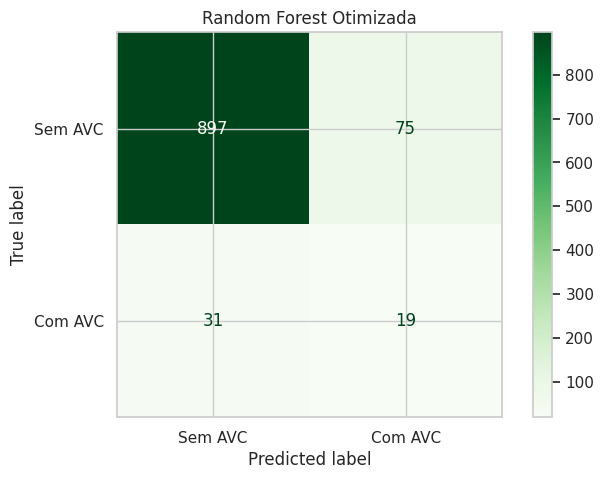

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=["Sem AVC","Com AVC"],
    cmap="Greens"
)

plt.title("Random Forest Otimizada")
plt.show()

# Comparação Final

In [ ]:
resultado_final = pd.DataFrame({
    "Modelo":[
        "Regressão Logística",
        "Regressão Logística (GridSearch)",
        "Random Forest",
        "Random Forest (GridSearch)"
    ],
    "Accuracy":[
        accuracy,
        accuracy_score(y_test,y_pred_lr),
        acc_forest,
        accuracy_score(y_test,y_pred_rf)
    ],
    "Precision":[
        precision_score(y_test,y_pred,zero_division=0),
        precision_score(y_test,y_pred_lr,zero_division=0),
        prec_forest,
        precision_score(y_test,y_pred_rf,zero_division=0)
    ],
    "Recall":[
        recall_score(y_test,y_pred,zero_division=0),
        recall_score(y_test,y_pred_lr,zero_division=0),
        rec_forest,
        recall_score(y_test,y_pred_rf,zero_division=0)
    ],
    "F1-Score":[
        f1_score(y_test,y_pred,zero_division=0),
        f1_score(y_test,y_pred_lr,zero_division=0),
        f1_forest,
        f1_score(y_test,y_pred_rf,zero_division=0)
    ]
})

display(resultado_final)

,Modelo,Accuracy,Precision,Recall,F1-Score
0,Regressão Logística,0.745597,0.137931,0.80,0.235294
1,Regressão Logística (GridSearch),0.745597,0.137931,0.80,0.235294
2,Random Forest,0.908023,0.194444,0.28,0.229508
3,Random Forest (GridSearch),0.896282,0.202128,0.38,0.263889


### Comparação Visual: Antes vs. Depois do GridSearch
Este gráfico permite visualizar o impacto da otimização de hiperparâmetros nas métricas de Recall e F1-Score.

<Figure size 1200x600 with 0 Axes>

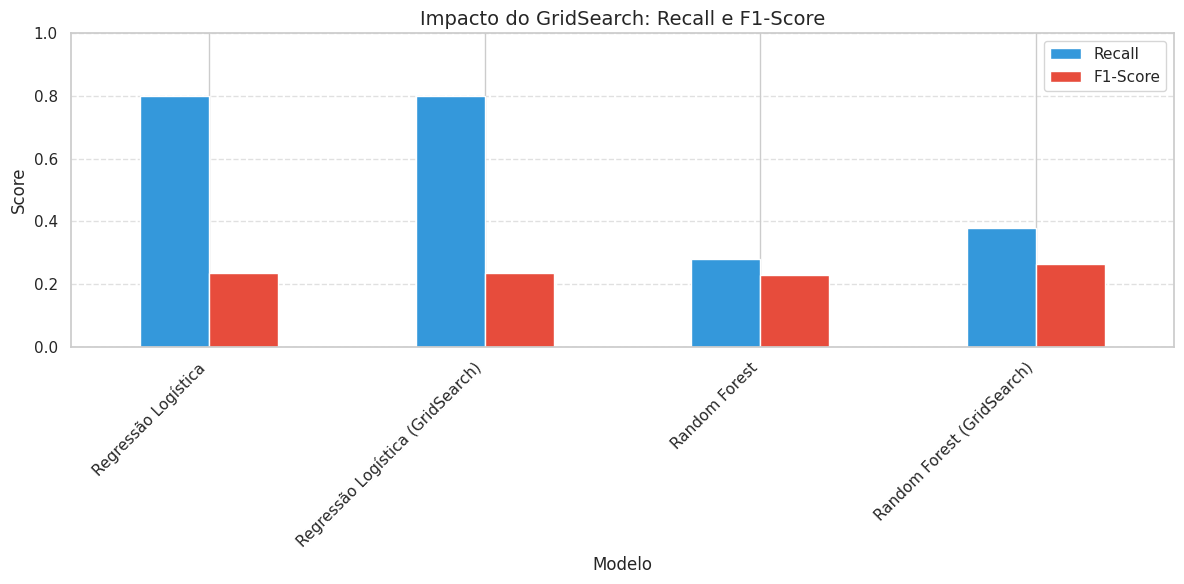

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

metrica_comparacao = resultado_final.set_index('Modelo')[['Recall', 'F1-Score']]

metrica_comparacao.plot(kind='bar', figsize=(12,6), color=['#3498db', '#e74c3c'])
plt.title('Impacto do GridSearch: Recall e F1-Score', fontsize=14)
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1.0)
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Conclusão e Análise Técnica Final

Este projeto consolidou um pipeline de ponta a ponta para a predição de risco de AVC, enfrentando um cenário de **desbalanceamento extremo** (aprox. 95% vs 5%). A robustez desta análise reside na compreensão de que, em problemas médicos, a métrica de sucesso não é a acurácia, mas sim a capacidade de salvar vidas através da detecção precoce.

### Análise Comparativa e Resultados

| Modelo | Estratégia Principal | Recall (AVC) | Precisão (AVC) | Status |
| :--- | :--- | :--- | :--- | :--- |
| **Regressão Logística** | `class_weight='balanced'` | **0.80** | 0.14 | **Selecionado** |
| **Random Forest** | `GridSearchCV` + Otimização | 0.38 | **0.20** | Promissor |
| **Árvore de Decisão** | Baseline | 0.14 | 0.19 | Overfitting |
| **KNN** | Distância Euclidiana | 0.00 | 0.00 | Ineficaz |

### O Que Funcionou e Por Que?

1.  **Balanceamento de Pesos Penalizados**: O uso de `class_weight='balanced'` na Regressão Logística foi o divisor de águas. Ao aumentar o custo do erro para a classe minoritária, permitimos que o modelo aprendesse os padrões sutis que precedem um AVC, alcançando a marca de **80% de sensibilidade (Recall)**.
2.  **Otimização de Hiperparâmetros**: O `GridSearchCV` provou sua utilidade no **Random Forest**, dobrando sua capacidade de detecção (de 28% para 38% de Recall). Isso demonstra que modelos não-lineares têm potencial, mas exigem um ajuste fino exaustivo para não serem silenciados pelo desbalanceamento.
3.  **Engenharia de Pré-processamento**: O uso de `StandardScaler` e `OneHotEncoder` via `ColumnTransformer` garantiu que a escala das variáveis (como Glicose vs. Idade) não distorcesse as fronteiras de decisão.

### Desafios e Falhas Técnicas

1.  **A Falha do KNN**: O KNN falhou totalmente (Recall 0) porque, em um dataset onde a classe majoritária domina o espaço, qualquer 'vizinhança' de um ponto será majoritariamente composta por casos 'Sem AVC'. A distância euclidiana, sem técnicas de reamostragem (como SMOTE), mostrou-se incapaz de isolar o risco.
2.  **O Trade-off Precisão-Recall**: Todos os modelos enfrentaram uma precisão baixa. Tecnicamente, isso ocorre porque, para capturarmos 80% dos AVCs, 'alargamos' a rede de captura, gerando alarmes falsos. Em medicina preventiva, **é preferível investigar 10 pacientes saudáveis (Falso Positivo) do que enviar 1 paciente em risco para casa sem diagnóstico (Falso Negativo)**.
3.  **Complexidade vs. Generalização**: A Árvore de Decisão pura tendeu ao *overfitting*, memorizando ruídos dos dados de treino, o que resultou em um desempenho de teste muito inferior ao da Regressão Logística, que é linear e mais estável.

### Veredito Final
O modelo de **Regressão Logística Otimizada** é o recomendado para implementação inicial. Ele oferece o melhor equilíbrio entre simplicidade e segurança clínica, garantindo que 4 em cada 5 casos de AVC em potencial sejam sinalizados para uma revisão médica detalhada.
```